In [6]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
from glob import glob

In [21]:
def read_nc(fpath):
    #Read NetCDF output file
    print(fpath)

    ds = nc.Dataset(fpath)

    data = {}

    data['t'] = np.array(ds["tmpl"][:], copy=True, dtype=float)
    data['p'] = np.array(ds["pl"][:], copy=True, dtype=float)
    data['r'] = np.array(ds["rl"][:], copy=True, dtype=float)

    data['baLW'] = np.array(ds["ba_U_LW"][:], copy=True, dtype=float)
    data['baSW'] = np.array(ds["ba_U_SW"][:], copy=True, dtype=float)
    data['baMA'] = np.array(ds["bandmax"][:], copy=True, dtype=float)
    data['baMI'] = np.array(ds["bandmin"][:], copy=True, dtype=float)

    data['baCE'] = 0.5*(data['baMA'] + data['baMI'])
    data['baWD'] = data['baMA'] - data['baMI']

    ds.close()

    return data


In [22]:
outdir = "../../nogit_h2s/"
dirs = glob(outdir + "*/")

data = {}
for d in dirs:
    h2s = float(d.split("/")[-2].split("_")[-1])
    fpath = d + "atm.nc"
    data[h2s] = read_nc(fpath)

../../nogit_h2s/out_10.0/atm.nc
../../nogit_h2s/out_30.0/atm.nc
../../nogit_h2s/out_03.0/atm.nc
../../nogit_h2s/out_01.0/atm.nc
../../nogit_h2s/out_00.3/atm.nc
../../nogit_h2s/out_00.1/atm.nc


0.1


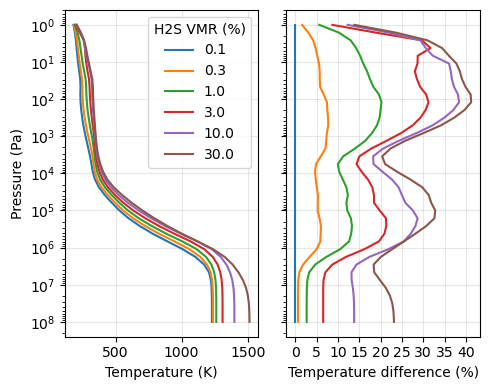

In [40]:
fig,axs = plt.subplots(1,2,figsize=(5,4), sharey=True)
axl, axr = axs

keys = sorted(data.keys())
k0 = keys[0]
print(k0)
d0 = data[k0]

for k in keys:
    d = data[k]
    axl.plot(d['t'], d['p'], label=k)
    axr.plot(100*(d['t']-d0['t'])/d0['t'], d['p'])

axl.grid(alpha=0.3)
axl.invert_yaxis()
axl.set_yscale("log")
axl.set_xlabel('Temperature (K)')
axl.set_ylabel('Pressure (Pa)')
axl.legend(title="H2S VMR (%)")

axr.grid(alpha=0.3)
axr.set_xlabel('Temperature difference (%)')
axr.xaxis.set_major_locator(mpl.ticker.MultipleLocator(5))

fig.tight_layout()

plt.show()
fig.savefig(outdir+"compare_h2s_temp.png", dpi=400)

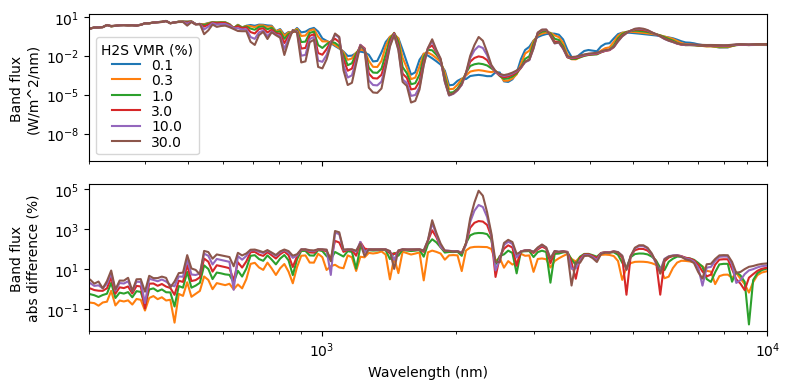

In [39]:
fig,axs = plt.subplots(2,1,figsize=(8,4), sharex=True)
axt, axb = axs


w0 = d0['baWD'] * 1e9
y0 = (d0['baLW'][0,:] + d0['baSW'][0,:])/w0

for k in keys:
    d = data[k]

    x = d['baCE'] * 1e9
    w = d['baWD'] * 1e9
    y = (d['baLW'][0,:] + d['baSW'][0,:])/w

    axt.plot(x, y, label=k)
    axb.plot(x, 100*np.abs(y-y0)/y0, label=k)

axt.set_yscale("log")
axt.set_ylabel("Band flux\n(W/m^2/nm)")
axt.legend(title="H2S VMR (%)", loc='lower left', labelspacing=0.1)

axb.set_xscale("log")
axb.set_xlabel("Wavelength (nm)")
axb.set_yscale("log")
axb.set_ylabel("Band flux\nabs difference (%)")

axb.set_xlim(left=300, right=10e3)

fig.tight_layout()

plt.show()
fig.savefig(outdir+"compare_h2s_spec.png", dpi=400)